# Human-in-The-Loop (HITL)

## Import Required Modules

In [54]:
import os
from sarvamai import SarvamAI
from dotenv import load_dotenv
from langchain_core.outputs import ChatResult, ChatGeneration
from typing import Any, Dict, List, Optional, Annotated, TypedDict
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, AnyMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command


from IPython.display import display, Markdown
load_dotenv()

True

## Custom LangChain Chat Wrapper for Sarvam

In [ ]:
class ChatSarvam(BaseChatModel):
    api_key: str = Field(...)
    temperature: float = 0.5
    top_p: float = 1
    max_tokens: int = 1000

    _client: SarvamAI = PrivateAttr()   # ✅ Private attribute

    def model_post_init(self, __context: Any) -> None:
        self._client = SarvamAI(
            api_subscription_key=self.api_key
        )

    @property
    def _llm_type(self) -> str:
        return "sarvam-chat-model"

    def _generate(
        self,
        messages: List[BaseMessage],
        stop: Optional[List[str]] = None,
        **kwargs: Any,
    ) -> ChatResult:

        sarvam_messages = []
        for msg in messages:
            if isinstance(msg, HumanMessage):
                role = "user"
            elif isinstance(msg, AIMessage):
                role = "assistant"
            else:
                role = "system"

            sarvam_messages.append({
                "role": role,
                "content": msg.content
            })

        response = self._client.chat.completions(
            messages=sarvam_messages,
            temperature=self.temperature,
            top_p=self.top_p,
            max_tokens=self.max_tokens,
        )

        content = response.choices[0].message.content

        return ChatResult(
            generations=[
                ChatGeneration(
                    message=AIMessage(content=content)
                )
            ]
        )

In [26]:
llm = ChatSarvam(api_key = os.getenv("SARVAM_API_KEY"))

In [27]:
response = llm.invoke(
    [HumanMessage(content = "Why is India called a land of diverse landscames?")]
)

print(response)

content=' India is often referred to as the **"land of diverse landscapes"** because it boasts an incredible variety of geographical features within its vast territory. From snow-capped mountains and sprawling deserts to lush forests, fertile plains, and coastal beaches, India\'s terrain is as varied as it is breathtaking. Here’s why:\n\n1. **Himalayan Mountains** – The world’s highest peaks, including Mount Everest, dominate the north.  \n2. **Indus-Gangetic Plains** – One of the world’s most fertile and densely populated regions.  \n3. **Thar Desert (Rajasthan)** – A vast arid desert with golden dunes and unique ecosystems.  \n4. **Western Ghats & Eastern Ghats** – Mountain ranges with dense forests, wildlife, and biodiversity hotspots.  \n5. **Coastal Plains** – Stretching along the Arabian Sea (west) and Bay of Bengal (east), with beaches, mangroves, and ports.  \n6. **Islands (Andaman & Nicobar, Lakshadweep)** – Pristine tropical islands with coral reefs and marine life.  \n7. **P

In [28]:
print(response.content)

 India is often referred to as the **"land of diverse landscapes"** because it boasts an incredible variety of geographical features within its vast territory. From snow-capped mountains and sprawling deserts to lush forests, fertile plains, and coastal beaches, India's terrain is as varied as it is breathtaking. Here’s why:

1. **Himalayan Mountains** – The world’s highest peaks, including Mount Everest, dominate the north.  
2. **Indus-Gangetic Plains** – One of the world’s most fertile and densely populated regions.  
3. **Thar Desert (Rajasthan)** – A vast arid desert with golden dunes and unique ecosystems.  
4. **Western Ghats & Eastern Ghats** – Mountain ranges with dense forests, wildlife, and biodiversity hotspots.  
5. **Coastal Plains** – Stretching along the Arabian Sea (west) and Bay of Bengal (east), with beaches, mangroves, and ports.  
6. **Islands (Andaman & Nicobar, Lakshadweep)** – Pristine tropical islands with coral reefs and marine life.  
7. **Plateaus (Deccan Pl

In [30]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [31]:
def chat_node(state: ChatState):
    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })

    if decision["approved"].lower() == "no":
        return {"messages": [AIMessage(content = "Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}

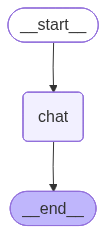

In [ ]:
checkpointer = MemorySaver() # Checkpointer is required for HITL

builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

app = builder.compile(checkpointer=checkpointer)
app

In [43]:
config = {"configurable": {"thread_id": "human-in-the-loop"}}

initial_input = {
    "messages": [("user", "Explain gradient descent in very simple terms.")]
}

result = app.invoke(initial_input, config=config)
print(result)

{'messages': [HumanMessage(content='Explan gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='4ac88b8e-1d37-40ca-87db-8afbeca0c72a'), AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='70493a02-be8c-47c5-b8d5-48386b75043b'), HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='09240e03-9f35-4c28-a30c-ecea5b0973f4')], '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='c0ee14eb196151716578d801adb9f780')]}


In [44]:
message = result["__interrupt__"][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [45]:
user_input = input(f"\nBackend message - {message}\nApprove this question? (y/n): ")

In [46]:
# resume the graph
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config = config
)

In [47]:
print(final_result)

{'messages': [HumanMessage(content='Explan gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='4ac88b8e-1d37-40ca-87db-8afbeca0c72a'), AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='70493a02-be8c-47c5-b8d5-48386b75043b'), HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='09240e03-9f35-4c28-a30c-ecea5b0973f4'), AIMessage(content=' Imagine you\'re at the top of a mountain and want to reach the lowest point (like a valley). Gradient descent is like **taking small steps downhill in the steepest direction** to find that lowest point. Here’s how it works:\n\n1. **Feel the slope**: At your current position, check which direction is steepest (this is the *gradient*).  \n2. **Take a step**: Move a little bit in that steepest direction.  \n3. **Repeat**: Keep doing this—check the slope again, then take another step—until you can’t go lower (you’ve reached 

In [55]:
display(Markdown(final_result["messages"][-1].content))

 Imagine you're at the top of a mountain and want to reach the lowest point (like a valley). Gradient descent is like **taking small steps downhill in the steepest direction** to find that lowest point. Here’s how it works:

1. **Feel the slope**: At your current position, check which direction is steepest (this is the *gradient*).  
2. **Take a step**: Move a little bit in that steepest direction.  
3. **Repeat**: Keep doing this—check the slope again, then take another step—until you can’t go lower (you’ve reached the valley).  

### Why it matters:
- It’s how computers learn the best "parameters" (like slopes in a line or weights in a model) to minimize error.  
- **Learning rate** = how big your steps are (too big = might miss the valley; too small = takes forever).  

### Simple example:
If you’re trying to fit a line to data points, gradient descent adjusts the line’s slope and intercept little by little until the line is as close as possible to all points.  

That’s it! It’s just **smart walking downhill**. 🚀